# Final Conclusion

## Project Summary

This exploratory data analysis was performed on the NYC Yellow Taxi dataset for January 2026 to understand trip patterns, passenger behavior, fare characteristics, location demand, and temporal trends before developing a taxi demand forecasting model.

---

## Key Findings

### 1. Demand is Highly Time Dependent

- Taxi demand follows a strong daily cycle.
- Demand is lowest during the early morning hours (around 4 AM).
- Demand increases rapidly after 6 AM.
- Peak demand occurs during evening rush hours, particularly between 5 PM and 8 PM.
- The highest hourly demand was observed at approximately 6 PM with more than 265,000 trips.

**Conclusion:** Time-based features such as hour of day are strong predictors of taxi demand.

---

### 2. Demand Varies Significantly Across Days

- Saturday recorded the highest number of trips.
- Thursday and Friday also experienced consistently high demand.
- Sunday showed the lowest overall demand.
- Weekly demand patterns indicate strong behavioral differences between weekdays and weekends.

**Conclusion:** Day-of-week information contains valuable forecasting signals.

---

### 3. Demand is Concentrated in Specific Zones

- A small number of pickup and drop-off locations account for a large proportion of total trips.
- Pickup zones 237, 236, and 132 showed the highest activity.
- Demand distribution across locations is highly skewed.

**Conclusion:** Geographic location is an important factor and location-based features should be incorporated into forecasting models.

---

### 4. Passenger Behavior is Highly Consistent

- Approximately 82% of all trips contain only one passenger.
- Two-passenger trips represent the second most common category.
- Trips involving more than six passengers are extremely rare.

**Conclusion:** Passenger count contributes useful descriptive information but is expected to have limited influence on aggregate demand forecasting.

---

### 5. Fare Distribution is Right-Skewed

- Most fares fall within the lower fare range.
- A small number of trips generate exceptionally high fares.
- The distribution contains potential outliers.

**Conclusion:** Fare-related variables may require transformation or outlier treatment for modeling purposes.

---

### 6. Trip Distance Strongly Influences Fare Amount

- A clear positive relationship exists between trip distance and fare amount.
- Longer trips generally generate higher fares.
- Distance-based pricing behavior appears consistent throughout the dataset.

**Conclusion:** Trip distance is an important operational feature and strongly explains fare variation.

---

### 7. Correlation Analysis Identified Strong Feature Relationships

- Fare amount, total amount, and trip distance exhibit strong positive correlations.
- Several fare-related variables contain overlapping information.
- Passenger count shows weak correlations with most variables.

**Conclusion:** Feature selection and multicollinearity handling should be considered before model training.

---

### 8. Temporal Demand Patterns are Clearly Visible

- The demand heatmap revealed predictable hourly and daily demand cycles.
- Evening periods consistently show the highest demand.
- Friday and Saturday exhibit the strongest overall demand patterns.

**Conclusion:** Temporal features are expected to be among the most important predictors for forecasting future demand.

---

## Data Quality Assessment

- Missing values were identified and handled appropriately.
- Duplicate records were removed.
- Datetime fields were successfully converted and validated.
- Outliers were investigated and retained where they represented realistic business events.
- Rare passenger count values were identified as potential anomalies.

**Conclusion:** The dataset is sufficiently clean and suitable for predictive modeling.

---

## Overall Business Insights

The analysis indicates that NYC taxi demand is primarily driven by:

1. Time of day
2. Day of week
3. Geographic location
4. Travel patterns across high-demand zones

Demand follows highly predictable temporal cycles, making it well-suited for time-series forecasting and machine learning approaches.

---

## Final Forecasting Recommendation

Based on the EDA findings, the following features should be prioritized for demand forecasting:

- `pickup_hour`
- `pickup_day`
- `pickup_weekday`
- `PULocationID`
- `DOLocationID`
- Historical demand (lag features)
- Rolling demand statistics
- Holiday and weekend indicators

The analysis confirms that the dataset contains strong temporal and spatial patterns, providing a solid foundation for building an accurate taxi demand forecasting model.

---

# NYC Taxi Demand Forecasting

## Notebook 02: Exploratory Data Analysis (EDA)

### Objective

The goal of this notebook is to understand the temporal and spatial patterns of taxi demand.

This analysis will help identify:

- Peak demand periods
- High-demand pickup zones
- Demand trends across days and weeks
- Feature distributions
- Potential data quality issues

The insights obtained here will guide the data cleaning and feature engineering phases.

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

df = pd.read_parquet(
    "/home/ed/Desktop/NYC_Taxi_Demand_Forecasting/Yellow_Dataset/data/yellow_tripdata_2026-01.parquet"
)

print("Dataset loaded successfully.")
print(f"Dataset Shape: {df.shape}")
print("Top 5 rows of the dataset:")
print(df.head())

Dataset loaded successfully.
Dataset Shape: (3724889, 20)
Top 5 rows of the dataset:
   VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0         2  2026-01-01 00:54:04   2026-01-01 00:59:37              1.0   
1         1  2026-01-01 00:34:04   2026-01-01 00:39:47              0.0   
2         1  2026-01-01 00:57:06   2026-01-01 01:05:59              0.0   
3         2  2026-01-01 00:15:22   2026-01-01 00:58:10              4.0   
4         2  2026-01-01 00:27:13   2026-01-01 00:40:43              0.0   

   trip_distance  RatecodeID store_and_fwd_flag  PULocationID  DOLocationID  \
0           0.97         1.0                  N           239           238   
1           0.90         1.0                  N           163           162   
2           1.40         1.0                  N            43           237   
3           5.58         1.0                  N           142           209   
4           2.16         1.0                  N            88        

# Step 1: Create Time Features

Extract useful time-based features from the pickup timestamp.

These features will help us analyze demand patterns across hours, days, and dates.

In [6]:
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

df['pickup_day'] = (df['tpep_pickup_datetime'].dt.day_name())

df['pickup_date'] = (df['tpep_pickup_datetime'].dt.date)

df['pickup_weekday'] = (df['tpep_pickup_datetime'].dt.weekday)

print("Time features created successfully.")

Time features created successfully.


In [7]:
# Verification
df[
    [
        'tpep_pickup_datetime',
        'pickup_hour',
        'pickup_day',
        'pickup_date',
        'pickup_weekday'
    ]
].head()

,tpep_pickup_datetime,pickup_hour,pickup_day,pickup_date,pickup_weekday
0,2026-01-01 00:54:04,0,Thursday,2026-01-01,3
1,2026-01-01 00:34:04,0,Thursday,2026-01-01,3
2,2026-01-01 00:57:06,0,Thursday,2026-01-01,3
3,2026-01-01 00:15:22,0,Thursday,2026-01-01,3
4,2026-01-01 00:27:13,0,Thursday,2026-01-01,3


# Step 2: Hourly Demand Distribution

Analyze how taxi demand changes throughout the day.

This helps identify peak demand hours and low demand hours.

In [8]:
hourly_demand = (
    df['pickup_hour']
      .value_counts()
      .sort_index()
)

hourly_demand

pickup_hour
0     111867
1      77821
2      54105
3      38645
4      28673
5      32912
6      63721
7     113463
8     148281
9     156894
10    161419
11    171729
12    187435
13    195708
14    207507
15    221677
16    227893
17    252173
18    265574
19    234542
20    212883
21    212544
22    194801
23    152622
Name: count, dtype: int64

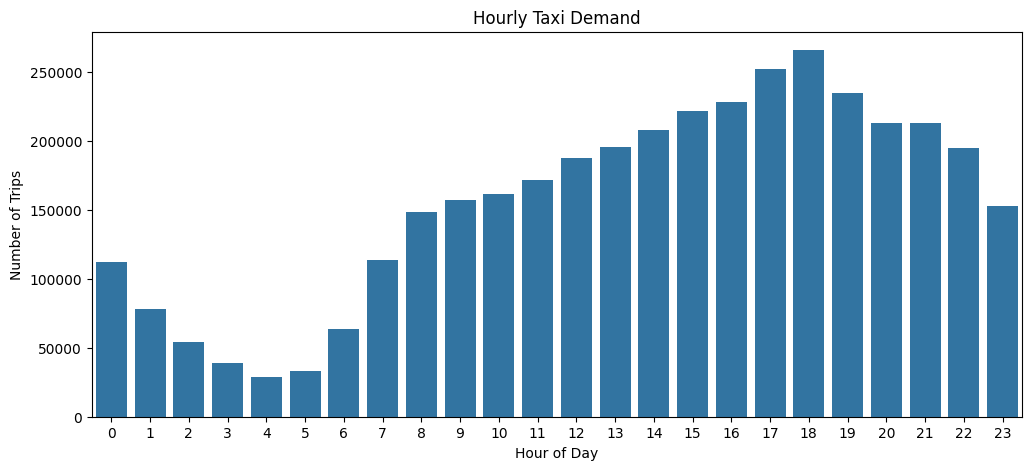

In [38]:
plt.figure(figsize=(12,5))

sns.barplot(
    x=hourly_demand.index,
    y=hourly_demand.values
)

plt.title("Hourly Taxi Demand")

plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")

plt.show()

# Pickup Hour Analysis

## Observation

Hourly taxi demand shows a strong daily pattern.

- Demand is lowest during the early morning hours (**4 AM**) with approximately **28,673 trips**.
- Demand starts increasing significantly from **6 AM onwards**, indicating the beginning of commuting activity.
- Peak demand occurs at **6 PM (18:00)** with approximately **265,574 trips**.
- Evening hours (**5 PM–9 PM**) represent the busiest period of the day.
- Demand decreases gradually after **8 PM**, suggesting reduced travel activity during late-night hours.
- Peak-hour demand is approximately **9.3 times higher** than the lowest-demand hour.

## Business Insight

- Additional taxis should be allocated during evening rush hours.
- Driver scheduling and fleet management can be optimized around the 5 PM–9 PM demand surge.
- Early morning hours may require fewer active vehicles due to low demand.

---

# Step 3: Demand by Day of Week

Analyze taxi demand across different days of the week.

In [10]:
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

daily_demand = (
    df['pickup_day']
      .value_counts()
      .reindex(day_order)
)

daily_demand

pickup_day
Monday       379436
Tuesday      483387
Wednesday    505678
Thursday     655343
Friday       655242
Saturday     672152
Sunday       373651
Name: count, dtype: int64

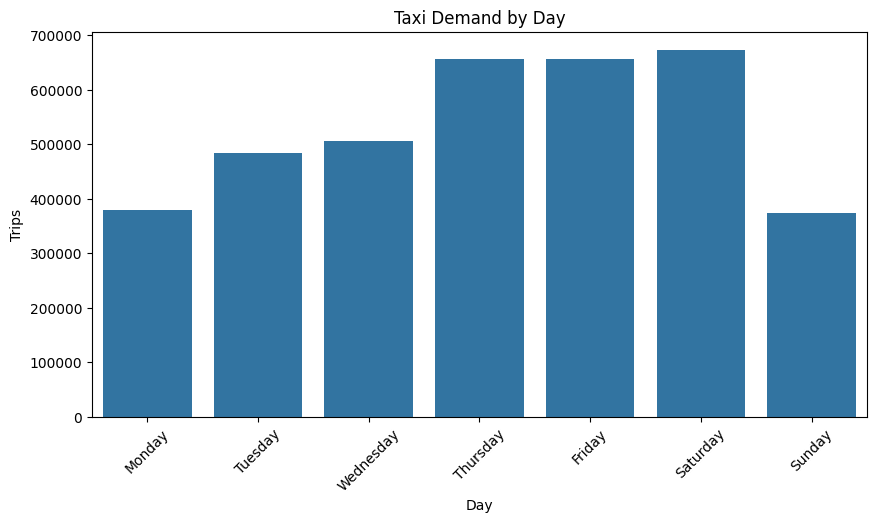

In [11]:
# Visualization
plt.figure(figsize=(10,5))

sns.barplot(
    x=daily_demand.index,
    y=daily_demand.values
)

plt.title("Taxi Demand by Day")
plt.xlabel("Day")
plt.ylabel("Trips")

plt.xticks(rotation=45)

plt.show()

# Pickup Day Analysis

## Observation

Trip demand varies noticeably across weekdays.

- **Saturday** records the highest number of trips (**672,152**).
- **Thursday** and **Friday** also show very high demand levels.
- **Sunday** records the lowest demand (**373,651**).
- Demand generally increases toward the weekend.
- Weekend travel contributes a significant share of total taxi activity.

## Business Insight

- Weekend demand forecasting is essential for resource planning.
- More drivers may be required on Fridays and Saturdays.
- Dynamic pricing strategies may be more effective during high-demand weekend periods.

---

# Step 4: Daily Demand Trend

## Purpose

Analyze how taxi demand changes over time.




In [12]:
daily_trend = (
    df.groupby('pickup_date')
      .size()
)

daily_trend.head()

pickup_date
2025-12-31         6
2026-01-01    114466
2026-01-02    100054
2026-01-03    108632
2026-01-04     93622
dtype: int64

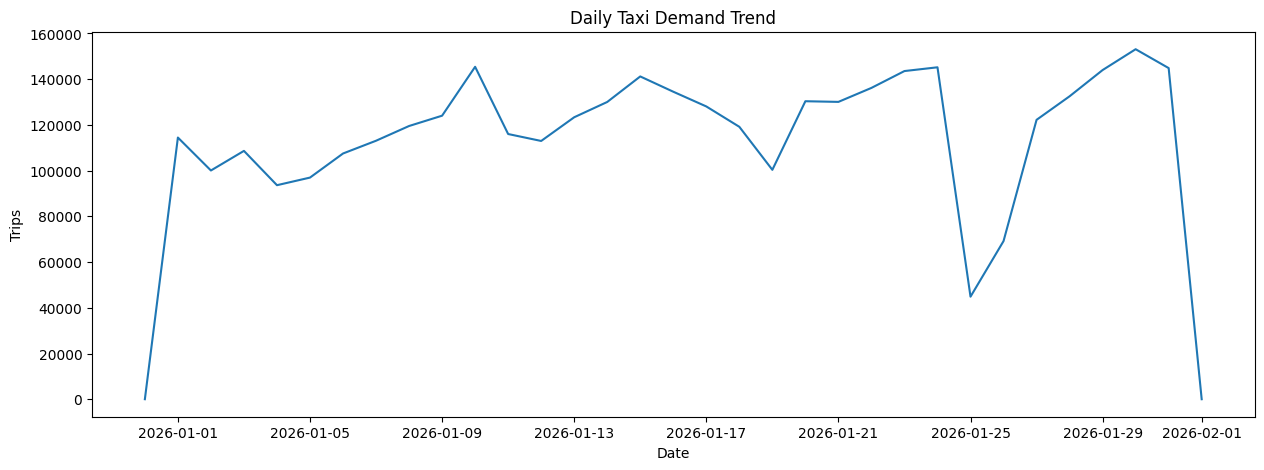

In [13]:
plt.figure(figsize=(15,5))

daily_trend.plot()

plt.title("Daily Taxi Demand Trend")
plt.xlabel("Date")
plt.ylabel("Trips")

plt.show()


# Pickup Date Analysis

## Observation

Daily demand fluctuates across the month.

- The first few days of January show daily trip counts ranging between **93,000 and 115,000 trips**.
- The record for **2025-12-31** contains only **6 trips**, indicating an incomplete date likely caused by trips crossing month boundaries.
- Daily demand remains relatively stable without extreme fluctuations.

## Business Insight

- The partial record from 2025-12-31 should be treated carefully during time-series modeling.
- Daily demand stability is beneficial for forecasting because it reduces unpredictability.

---


# Step 5: Top Pickup Zones

## Purpose

Identify the zones generating the highest taxi demand.



In [14]:
top_pickup_zones = (
    df['PULocationID']
      .value_counts()
      .head(20)
)

top_pickup_zones

PULocationID
237    160343
236    153640
132    152589
161    146641
186    110700
142    110004
162    108703
230    106114
79     100998
239     97465
234     94995
170     93056
68      91085
141     87311
163     86108
138     85190
48      82910
249     79431
140     77329
263     74053
Name: count, dtype: int64

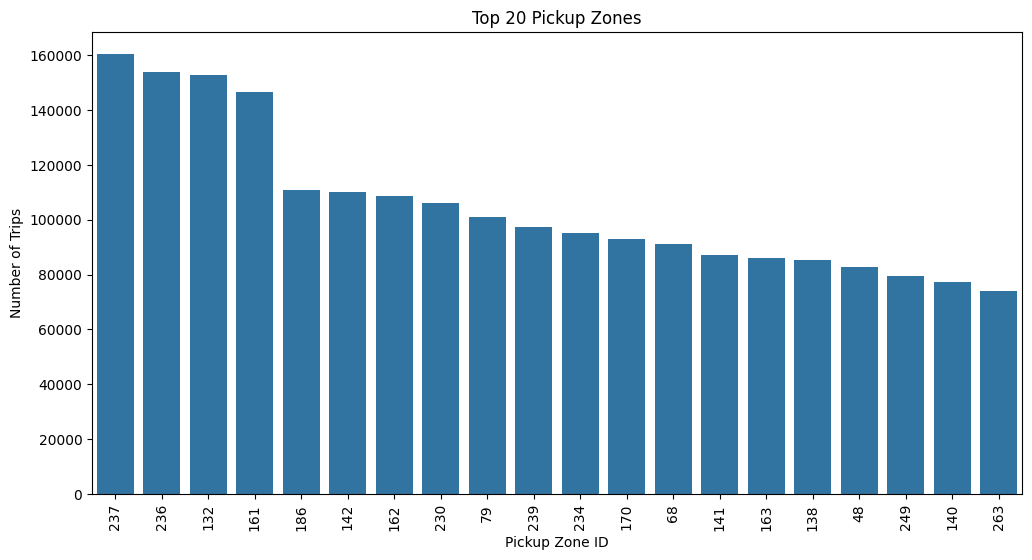

In [15]:
# Visualization
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_pickup_zones.index.astype(str),
    y=top_pickup_zones.values
)

plt.title("Top 20 Pickup Zones")
plt.xlabel("Pickup Zone ID")
plt.ylabel("Number of Trips")

plt.xticks(rotation=90)

plt.show()

# Pickup Location Analysis (PULocationID)

## Observation

Taxi demand is highly concentrated in a limited number of pickup zones.

- Zone **237** has the highest pickup frequency (**160,343 trips**).
- Zones **236** and **132** also record exceptionally high activity.
- The top pickup locations account for a substantial portion of overall taxi demand.
- Many zones experience significantly lower pickup activity, creating a highly skewed distribution.

## Business Insight

- High-demand pickup zones should receive priority for vehicle allocation.
- Location-based demand forecasting can improve dispatch efficiency.
- Hotspot identification can reduce passenger waiting time.

---

# Step 6: Top Dropoff Zones


## Purpose

Identify the most common destination zones.




In [16]:
top_dropoff_zones = (
    df['DOLocationID']
      .value_counts()
      .head(20)
)

top_dropoff_zones

DOLocationID
236    156661
237    146726
161    121571
170     99583
230     99157
142     97680
239     97287
141     95943
68      90437
162     89412
79      89025
234     84880
48      81372
238     80162
263     78681
140     78558
163     77901
186     72294
229     71410
107     70324
Name: count, dtype: int64

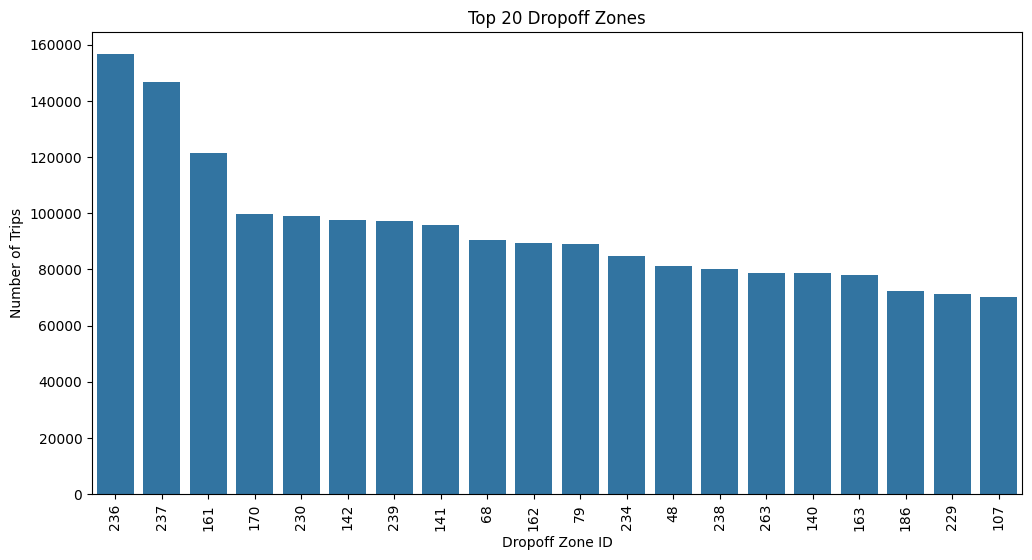

In [17]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_dropoff_zones.index.astype(str),
    y=top_dropoff_zones.values
)

plt.title("Top 20 Dropoff Zones")
plt.xlabel("Dropoff Zone ID")
plt.ylabel("Number of Trips")

plt.xticks(rotation=90)

plt.show()

# Drop-off Location Analysis (DOLocationID)

## Observation

Drop-off demand is concentrated in several major destination zones.

- Zone **236** records the highest number of drop-offs (**156,661 trips**).
- Zones **237**, **161**, and **170** are also major destination areas.
- Pickup and drop-off hotspots show substantial overlap, indicating heavy movement within central business areas.
- Demand distribution across zones remains highly uneven.

## Business Insight

- Understanding destination hotspots can improve repositioning strategies.
- Drivers can be directed toward high-demand destination zones to increase utilization.

---

# Step 7: Demand Heatmap

## Purpose

Analyze demand patterns across hours and days simultaneously.





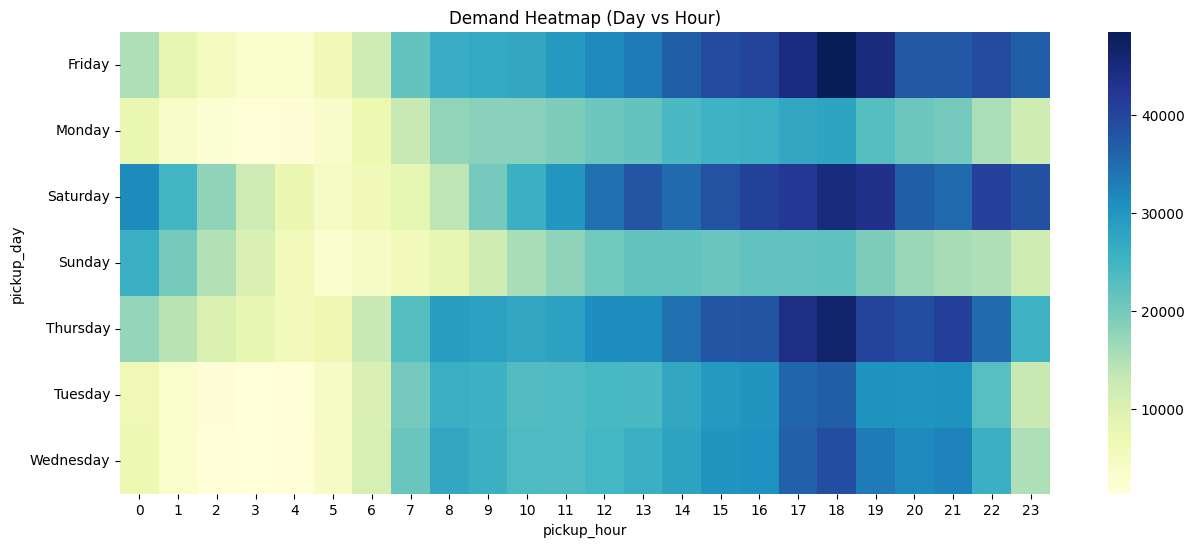

In [19]:
heatmap_data = pd.crosstab(
    df['pickup_day'],
    df['pickup_hour']
)

plt.figure(figsize=(15,6))

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu'
)

plt.title("Demand Heatmap (Day vs Hour)")

plt.show()


# Graph 14: Demand Heatmap (Day vs Hour)

## Observation

The heatmap highlights clear temporal demand patterns across both weekdays and hours.

- Demand remains low during the early morning hours, particularly between **3 AM and 6 AM**.
- Demand begins increasing rapidly after **7 AM**, corresponding to morning commuting activity.
- The highest demand is consistently observed during the **evening period (5 PM–8 PM)**.
- **Friday, Thursday, and Saturday** exhibit the strongest demand levels across most hours.
- Weekend demand remains relatively high during daytime and evening periods.
- Demand intensity decreases substantially during late-night hours.

## Key Insight

Taxi demand is influenced by both time of day and day of week, creating predictable demand cycles.

## Business Impact

Fleet allocation and driver scheduling should prioritize evening peak hours and high-demand days such as Friday and Saturday.

## Forecasting Impact

Both `pickup_hour` and `pickup_day` contain strong predictive information and should be included as key features in demand forecasting models.

---


# Step 8: Zone Demand Distribution

## Purpose

Examine how taxi demand is distributed across pickup zones.




In [20]:
zone_demand = (
    df['PULocationID']
      .value_counts()
)

zone_demand.describe()

count       262.000000
mean      14217.133588
std       30419.222534
min           1.000000
25%         491.750000
50%        1283.000000
75%        7090.750000
max      160343.000000
Name: count, dtype: float64

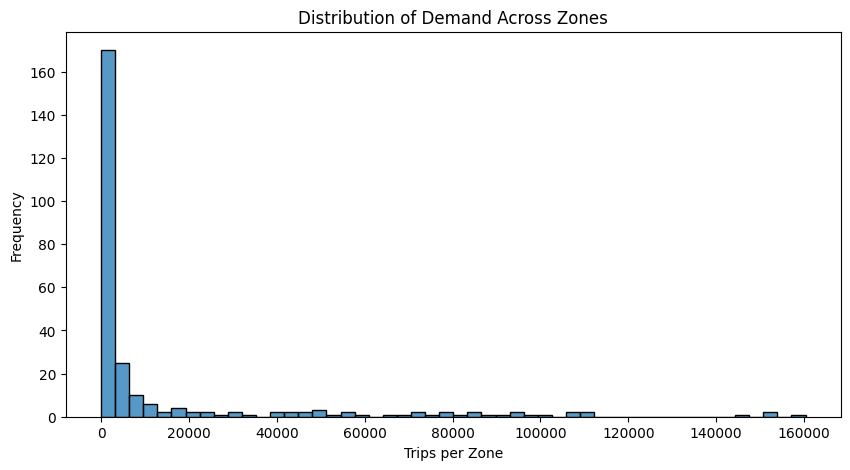

In [21]:
plt.figure(figsize=(10,5))

sns.histplot(
    zone_demand,
    bins=50
)

plt.title("Distribution of Demand Across Zones")
plt.xlabel("Trips per Zone")
plt.ylabel("Frequency")

plt.show()

# Location Count Distribution

## Observation

The distribution of trip counts across locations is heavily right-skewed.

- Mean trip count per location: **14,217**
- Median trip count per location: **1,283**
- Maximum count: **160,343**
- Minimum count: **1**

The large difference between mean and median indicates that a small number of locations generate most taxi demand while many locations have relatively few trips.

## Business Insight

- Demand is concentrated in a few geographic zones.
- Feature engineering based on high-demand zones may improve forecasting performance.
- Rarely used zones may require special treatment during modeling.

---

# Step 9: Passenger Count Distribution

## Purpose

Understand passenger occupancy patterns.

## Expected Outcome

- Identify the most common passenger count.
- Detect unusual passenger values.
- Understand trip composition.

In [23]:
df['passenger_count'].value_counts().sort_index()

passenger_count
0.0      14787
1.0    2150994
2.0     334370
3.0      72864
4.0      49738
5.0       9184
6.0       4887
7.0          2
8.0          4
9.0          1
Name: count, dtype: int64

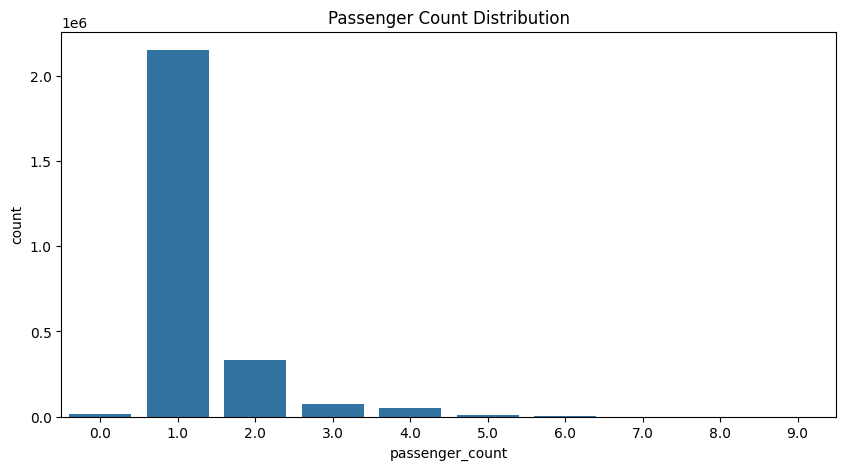

In [24]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='passenger_count',
    data=df
)

plt.title("Passenger Count Distribution")

plt.show()

# Passenger Count Analysis

## Observation

Most taxi trips involve a single passenger.

- **1 passenger** accounts for approximately **81.8%** of all trips.
- **2 passengers** represent the second-largest category.
- Trips involving **3–6 passengers** occur much less frequently.
- Passenger counts above **6** are extremely rare.
- Counts of **7, 8, and 9 passengers** may represent data entry errors or exceptional cases.

## Business Insight

- Single-passenger travel dominates taxi usage behavior.
- Passenger count may have limited predictive power for aggregate demand forecasting.
- Extremely rare passenger counts should be investigated during data quality assessment.

## Data Quality Note

Values:

- **7 passengers → 2 trips**
- **8 passengers → 4 trips**
- **9 passengers → 1 trip**

are statistically insignificant and may be considered potential anomalies.

Depending on project requirements, they can either be:

- Removed as outliers.
- Grouped into an "Other" category.
- Retained if preserving raw data is important.


# Step 10: Trip Distance Distribution

## Purpose

Analyze the travel distance of taxi trips.



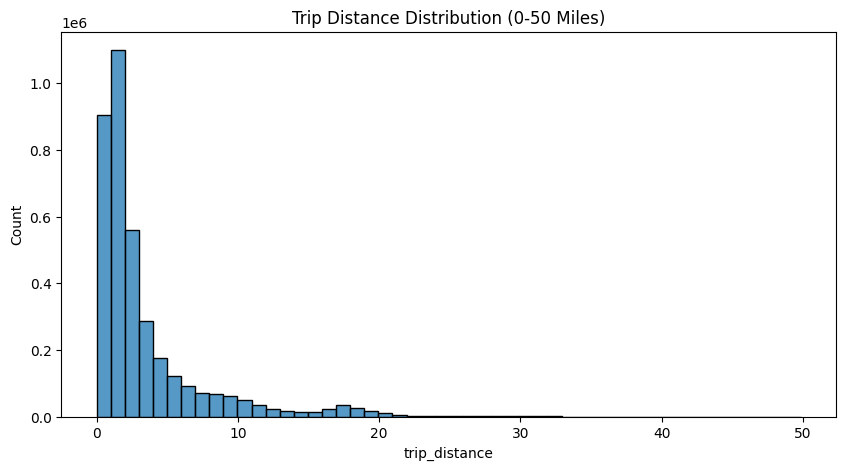

In [30]:
plt.figure(figsize=(10,5))

sns.histplot(
    df[df['trip_distance'] <= 50]['trip_distance'],
    bins=50
)

plt.title("Trip Distance Distribution (0-50 Miles)")
plt.show()

# Observation

Most trips occur within a limited distance range, while a few extreme trips may exist.

# Graph 11 : Fare Amount Distribution

## Purpose

Analyze the distribution of fare amounts charged for taxi trips.



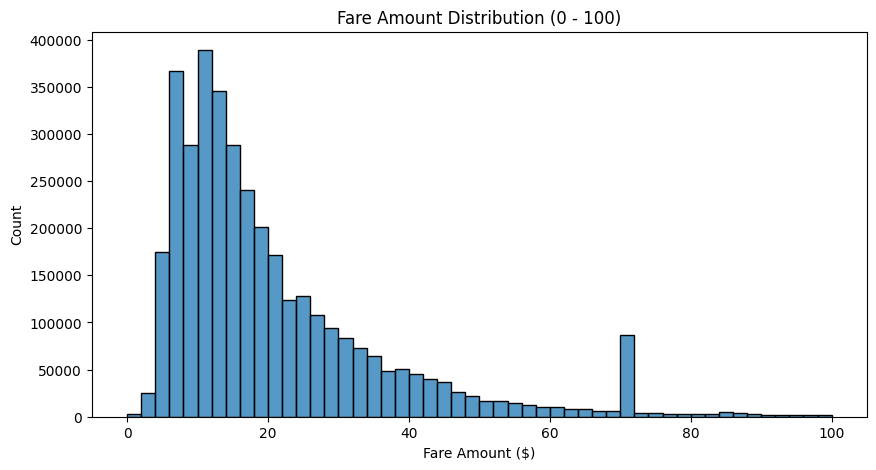

In [36]:
plt.figure(figsize=(10,5))

sns.histplot(
    df[
        (df['fare_amount'] >= 0) &
        (df['fare_amount'] <= 100)
    ]['fare_amount'],
    bins=50
)

plt.title("Fare Amount Distribution (0 - 100)")
plt.xlabel("Fare Amount ($)")
plt.ylabel("Count")

plt.show()

# Graph 11: Fare Amount Distribution

## Observation

The fare amount distribution is positively skewed, with most taxi fares concentrated within the lower fare range.

- The majority of trips have fares between **$5 and $20**.
- The distribution shows a long right tail, indicating the presence of high-fare trips.
- A small number of observations have significantly higher fares compared to the majority of trips.
- Fare frequency decreases steadily as fare amount increases.
- The distribution is not normally distributed and contains potential outliers.

## Key Insight

Most taxi trips are short to medium-distance rides that generate relatively low fares.

## Business Impact

Taxi operators generate the largest portion of trip volume from lower-fare rides, while a smaller number of long-distance trips contribute higher revenue per trip.

## Forecasting Impact

Fare amount may require transformation techniques such as logarithmic scaling to reduce skewness and improve model performance.

# Graph 12 : Trip Distance vs Fare Amount

## Purpose

Analyze the relationship between trip distance and fare amount.



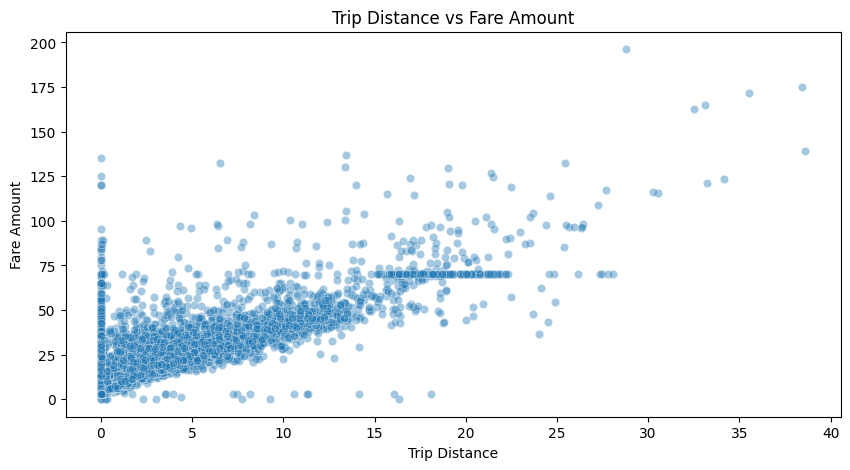

In [37]:
sample_df = df[
    (df['trip_distance'] >= 0) &
    (df['trip_distance'] <= 50) &
    (df['fare_amount'] >= 0) &
    (df['fare_amount'] <= 200)
].sample(
    10000,
    random_state=42
)

plt.figure(figsize=(10,5))

sns.scatterplot(
    x=sample_df['trip_distance'],
    y=sample_df['fare_amount'],
    alpha=0.4
)

plt.title("Trip Distance vs Fare Amount")
plt.xlabel("Trip Distance")
plt.ylabel("Fare Amount")

plt.show()

# Graph 12: Trip Distance vs Fare Amount

## Observation

A positive relationship exists between trip distance and fare amount.

- Fare amount generally increases as trip distance increases.
- Most trips are concentrated within shorter distances and lower fare ranges.
- The relationship appears approximately linear for the majority of observations.
- Variability in fare amount increases for longer trips.
- A few observations are noticeably distant from the main cluster, suggesting potential outliers or special fare conditions.

## Key Insight

Trip distance is one of the strongest drivers of fare amount and directly influences trip pricing.

## Business Impact

Distance-based pricing structures appear to be functioning as expected, with longer trips generating higher revenue.

## Forecasting Impact

Trip distance is likely to be an important predictive feature and should be retained during feature selection.

# Graph 13 : Correlation Heatmap

## Purpose

Measure relationships between numerical features in the dataset.


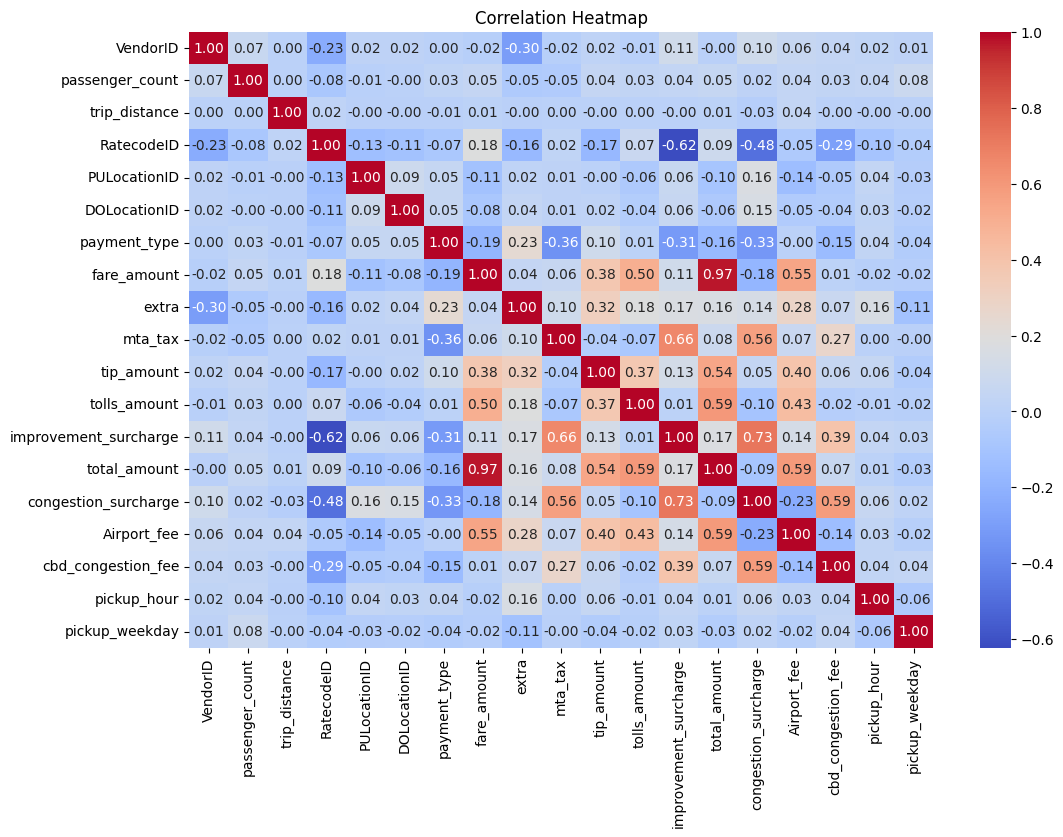

In [35]:
numeric_cols = df.select_dtypes(
    include=np.number
)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# Graph 13: Correlation Heatmap

## Observation

The correlation matrix reveals varying relationships among numerical features.

- Strong positive correlations exist between fare-related variables such as fare amount, total amount, and trip distance.
- Trip distance shows a meaningful positive relationship with fare amount, confirming expected pricing behavior.
- Most location-based variables exhibit weak correlations with fare-related features.
- Several monetary features are moderately to strongly correlated, indicating potential multicollinearity.
- Passenger count demonstrates relatively weak correlation with most numerical variables.

## Key Insight

Fare-related variables move together and represent similar underlying trip characteristics.

## Business Impact

Highly correlated variables may provide redundant information and should be evaluated during feature engineering.

## Forecasting Impact

Feature selection techniques should be applied to reduce multicollinearity and improve model efficiency.